In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import Predictive

###PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

###Forward and Backward Selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm

# HMC
from pyro.infer import MCMC, NUTS

# variational inference
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange


import matplotlib as mpl
import os
import sys
import math
from optbnn.gp.models.gpr import GPR
from optbnn.gp import kernels, mean_functions, priors
from optbnn.bnn.reparam_nets import GaussianMLPReparameterization
from optbnn.bnn.nets.mlp import MLP
from optbnn.bnn.likelihoods import LikGaussian
from optbnn.bnn.priors import FixedGaussianPrior, OptimGaussianPrior
from optbnn.prior_mappers.wasserstein_mapper import MapperWasserstein, WassersteinDistance
from optbnn.utils.rand_generators import MeasureSetGenerator, GridGenerator
from optbnn.utils.normalization import normalize_data
from optbnn.utils.exp_utils import get_input_range
from optbnn.metrics.sampling import compute_rhat_regression
from optbnn.metrics import uncertainty as uncertainty_metrics
from optbnn.sgmcmc_bayes_net.regression_net import RegressionNet
from optbnn.utils import util

### 1. concatenated records

#### 1.1 records before GDPR

In [34]:
df_pre = pd.read_csv("pregdpr_ASML.csv")
df_pre.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,433332427,75.32,10,1,1.512459,433332427,75.63,10,1,1.512459,...,79.00,10,1,1.512459,433332427,79.03,10,1,1.512459,80.671083
1,433332427,75.63,10,1,1.512459,433332427,78.37,10,1,1.512459,...,79.03,10,1,1.512459,433332427,79.50,10,1,1.512459,79.804729
2,433332427,78.37,10,1,1.512459,433332427,79.00,10,1,1.512459,...,79.50,10,1,1.512459,433332427,79.52,10,1,1.512459,79.335644
3,433332427,79.00,10,1,1.512459,433332427,79.03,10,1,1.512459,...,79.52,10,1,1.512459,433332427,78.80,10,1,1.512459,78.684095
4,433332427,79.03,10,1,1.512459,433332427,79.50,10,1,1.512459,...,78.80,10,1,1.512459,433332427,77.51,10,1,1.512459,75.801294


In [35]:
X_pre = df_pre.iloc[:, : -1].values
X_pre, X_pre.shape, type(X_pre)

(array([[4.33332427e+08, 7.53200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51245898e+00],
        [4.33332427e+08, 7.56300000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51245898e+00],
        [4.33332427e+08, 7.83700000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51245898e+00],
        ...,
        [4.25659704e+08, 2.62750000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.58509111e+00],
        [4.25659704e+08, 2.62550000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.58509111e+00],
        [4.25659704e+08, 2.60050000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.58509111e+00]]),
 (481, 25),
 numpy.ndarray)

In [36]:
y_pre = df_pre["target"].values
y_pre, y_pre.shape, type(y_pre)

(array([80.67108347, 79.80472942, 79.33564356, 78.68409502, 75.80129409,
        77.80076938, 77.02430528, 77.47746709, 77.09960411, 79.63476683,
        79.96593059, 80.65853497, 79.75040827, 79.83639378, 80.32007713,
        79.95457892, 80.28695432, 80.68086334, 80.98152394, 81.77264625,
        81.89794912, 82.96128761, 83.65991196, 82.34674949, 81.88974064,
        82.42331847, 81.66053234, 81.09093807, 80.39777823, 80.52917051,
        80.02177691, 79.7158773 , 78.81394558, 78.6883482 , 79.07502971,
        79.44246995, 79.59623198, 79.24150349, 79.62632016, 79.67846028,
        79.13854648, 79.22283869, 79.3074635 , 79.05955144, 79.11754983,
        78.32202946, 78.63138635, 77.95367169, 79.31251875, 77.88712144,
        77.93496532, 77.82833858, 79.38036703, 79.55235126, 79.20238692,
        78.55080004, 78.63015156, 78.50328269, 78.91555084, 77.85814064,
        77.58716882, 77.59107813, 76.81281424, 76.87046538, 74.81868689,
        77.01972587, 76.50593062, 75.45174278, 76.5

#### 1.2 records after GDPR

In [37]:
df_post = pd.read_csv("postgdpr_ASML.csv")
df_post.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,438271869.0,92.74,10.0,1.0,1.501852,438271869.0,91.65,10.0,1.0,1.501852,...,92.67,10.0,1.0,1.501852,438271869.0,93.54,10.0,1.0,1.501852,90.926551
1,438271869.0,91.65,10.0,1.0,1.501852,438271869.0,91.72,10.0,1.0,1.501852,...,93.54,10.0,1.0,1.501852,438271869.0,93.58,10.0,1.0,1.501852,90.267417
2,438271869.0,91.72,10.0,1.0,1.501852,438271869.0,92.67,10.0,1.0,1.501852,...,93.58,10.0,1.0,1.501852,438271869.0,93.14,10.0,1.0,1.501852,87.091552
3,438271869.0,92.67,10.0,1.0,1.501852,438271869.0,93.54,10.0,1.0,1.501852,...,93.14,10.0,1.0,1.501852,438271869.0,90.75,10.0,1.0,1.501852,84.982888
4,438271869.0,93.54,10.0,1.0,1.501852,438271869.0,93.58,10.0,1.0,1.501852,...,90.75,10.0,1.0,1.501852,438271869.0,87.65,10.0,1.0,1.501852,86.355830


In [38]:
X_post = df_post.iloc[:, : -1].values
X_post, X_post.shape, type(X_post)

(array([[4.38271869e+08, 9.27400000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50185161e+00],
        [4.38271869e+08, 9.16500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50185161e+00],
        [4.38271869e+08, 9.17200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50185161e+00],
        ...,
        [4.31464705e+08, 1.67000000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56058307e+00],
        [4.31464705e+08, 1.68150000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56058307e+00],
        [4.31464705e+08, 1.68450000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56058307e+00]]),
 (481, 25),
 numpy.ndarray)

In [69]:
y_post = df_post["target"].values
y_post, y_post.shape, type(y_post)

(array([ 90.92655083,  90.26741678,  87.09155197,  84.98288819,
         86.35582983,  86.49747126,  88.20382114,  97.67177364,
         96.63199027,  95.36812369,  96.33487166,  96.59104036,
         96.03029327,  96.09676153,  95.73137175,  95.21506721,
         94.68867711,  94.72218444,  94.10816966,  94.85957135,
         95.24110963,  94.3773192 ,  95.07698416,  95.63210342,
         95.45460791,  95.78254212,  96.08173041,  95.38327699,
         95.34076547,  95.1948458 ,  95.7475745 ,  96.605122  ,
         98.40206221,  98.27062257,  98.09487396,  96.66059485,
         97.08607843,  97.5173481 ,  97.37675454,  96.67139094,
         96.91348699,  95.32475136,  95.68910599,  94.865583  ,
         95.65770095,  96.40708473,  95.71277267,  95.1717671 ,
         95.53031227,  95.96523366,  95.28066258,  94.84419361,
         95.21984103,  94.6453716 ,  93.00358941,  92.79103972,
         94.98130341,  92.90259884,  92.89749716,  92.95455469,
         91.05907328,  90.3140624 ,  91.

### 2. BNN and plot functions

In [40]:
class BNN(PyroModule):
    def __init__(self, weight_prior, bias_prior, in_dim=1, out_dim=1, hid_dim=10, n_hid_layers=5):
        '''
        functional model (network architecture):
            a fully connected neural network.

        stochastic model:
            Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., weight_prior or bias_prior), where weight_prior and bias_prior are learned;
            Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
        '''
        super().__init__()

        # make sure the dimensions are valid
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # activation function for the whole network, can also be ReLU or LeakyReLU
        self.activation = nn.Tanh()

        # define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        # set the probability distribution for each layer's weight and bias
        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., weight_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., bias_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        # input --> hidden
        x = self.activation(self.layers[0](x))
        # hidden --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))
        # hidden --> output
        mu = self.layers[-1](x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))
        with pyro.plate("data", x.shape[0]):
            # obs is used when quantifying and visualizing the uncertainty of predictions
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=y)
        
        return mu

In [41]:
def plot_predictions(preds, y):
    '''
    Function to visualize the predictions and the uncertainty of predictions.
    '''
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))

    # decide the range of the y axis based on the number of the labels
    time_idx = np.array(range(len(y)))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    # decide the range of the y axis based on the range of the labels
    ylims = [min(y.min(), y_pred.min()) - 20,
             max(y.max(), y_pred.max()) + 20]
    
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("closing price", fontsize=20)

    ax.plot(time_idx, y, 'ko', markersize=1, label="observations")
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="#408765", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=0)

    plt.legend(loc=4, fontsize=15, frameon=False)

In [42]:
def plot_uncertainty(preds, y):
    '''
    Function to visualize only the uncertainty.
    '''
    fig, ax = plt.subplots(figsize=(10, 5))

    time_idx = np.array(range(len(y)))
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [y_std.min() - 0.5, y_std.max() + 0.5]

    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("std of closing price", fontsize=20)

    ax.plot(time_idx, y_std, 'ko', markersize=1, label="std of predictions")
    ax.plot(time_idx, y_std, '-', linewidth=0.5, color="#408765")

    plt.legend(loc=4, fontsize=15, frameon=False)

### 3. uncertainty quantification of data pre GDPR

#### 3.1 Train the prior of BNN.

In [57]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 200  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre, y_pre)
x_min, x_max = get_input_range(X_pre_n, X_pre_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 200),
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=0, gpu_gp=False)
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at ../aten/src/ATen/native/Resize.cpp:17.)
  return torch.log(torch.exp(t) - 1, out=out)
/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/models/model.py:136: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH().
This transform will produce

>>> Iteration #   1: Wasserstein Dist 9.3603
>>> Iteration #  10: Wasserstein Dist 5.6265
>>> Iteration #  20: Wasserstein Dist 3.3618
>>> Iteration #  30: Wasserstein Dist 1.9000
>>> Iteration #  40: Wasserstein Dist -0.0223
>>> Iteration #  50: Wasserstein Dist 0.9337
>>> Iteration #  60: Wasserstein Dist 1.2202
>>> Iteration #  70: Wasserstein Dist 2.4326
>>> Iteration #  80: Wasserstein Dist 1.4990
>>> Iteration #  90: Wasserstein Dist 1.5382
>>> Iteration # 100: Wasserstein Dist -0.6022
>>> Iteration # 110: Wasserstein Dist 0.5359
>>> Iteration # 120: Wasserstein Dist 1.5580
>>> Iteration # 130: Wasserstein Dist 0.9476
>>> Iteration # 140: Wasserstein Dist 1.2331
>>> Iteration # 150: Wasserstein Dist 2.2883
>>> Iteration # 160: Wasserstein Dist -1.1660
>>> Iteration # 170: Wasserstein Dist 0.2091
>>> Iteration # 180: Wasserstein Dist 0.7541
>>> Iteration # 190: Wasserstein Dist 1.7633
>>> Iteration # 200: Wasserstein Dist 0.2249
Saved intermediate wasserstein values in: ./exp/gdpr

In [58]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.6905], requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.9497], requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.3724], requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.8432], requires_grad=True)


In [59]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(3.6905), maintain_positivity(1.3724)]
pre_bias_prior = [maintain_positivity(2.9497), maintain_positivity(-0.8432)]

#### 3.2 train the BNN

In [63]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [65]:
num_epochs = 10000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0]))

  0%|          | 2/10000 [00:00<30:24,  5.48it/s, loss=54.030]

[iteration 0001] loss: 27.324


 50%|█████     | 5002/10000 [15:19<15:30,  5.37it/s, loss=19.049] 

[iteration 5001] loss: 19.238


100%|██████████| 10000/10000 [30:17<00:00,  5.50it/s, loss=14.512]


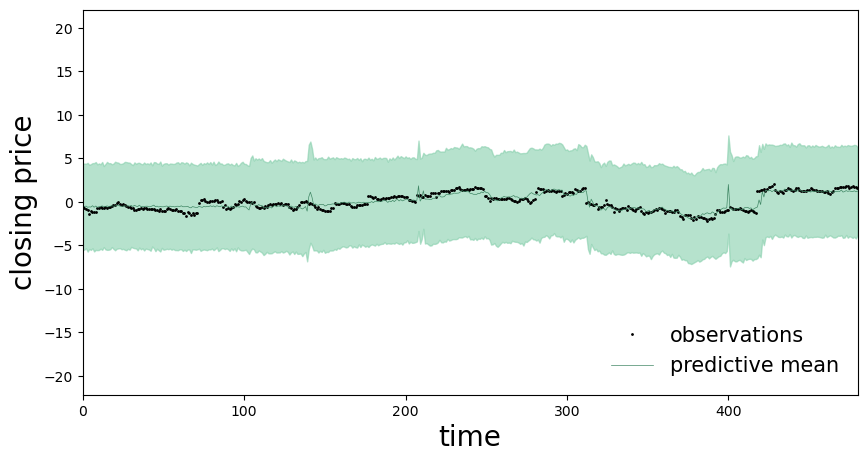

In [67]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_pre_n_tensor)

plot_predictions(preds, y_pre_n_tensor)

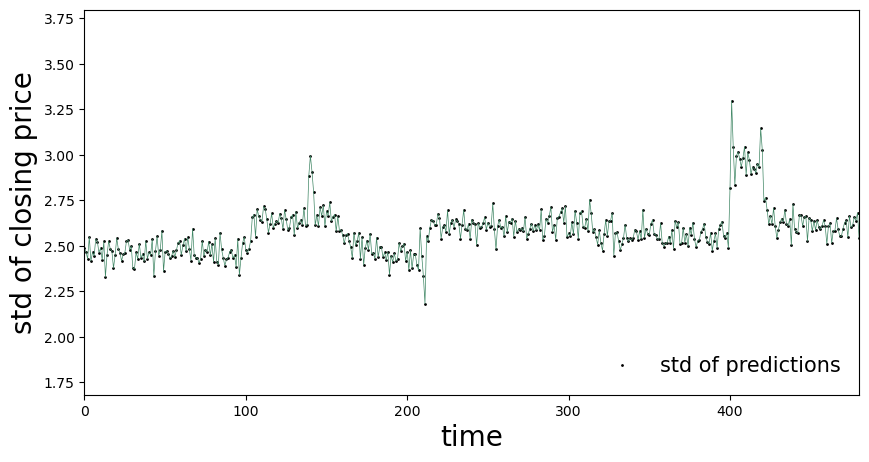

In [68]:
plot_uncertainty(preds, y_pre_n)

### 4. uncertainty quantification of data post GDPR

#### 4.1 Train the prior of BNN.

In [70]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 200  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post, y_post)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 200),
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=0, gpu_gp=False)
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

/home/shenkaichen/miniconda3/envs/IUQ_project/lib/python3.7/site-packages/optbnn/gp/parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at ../aten/src/ATen/native/Resize.cpp:17.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 8.7705
>>> Iteration #  10: Wasserstein Dist 1.2519
>>> Iteration #  20: Wasserstein Dist 1.5175
>>> Iteration #  30: Wasserstein Dist 0.6760
>>> Iteration #  40: Wasserstein Dist 0.6043
>>> Iteration #  50: Wasserstein Dist 1.5765
>>> Iteration #  60: Wasserstein Dist 1.1679
>>> Iteration #  70: Wasserstein Dist 0.9510
>>> Iteration #  80: Wasserstein Dist 0.5152
>>> Iteration #  90: Wasserstein Dist 1.5987
>>> Iteration # 100: Wasserstein Dist -0.4274
>>> Iteration # 110: Wasserstein Dist 0.8560
>>> Iteration # 120: Wasserstein Dist 1.3930
>>> Iteration # 130: Wasserstein Dist 0.4719
>>> Iteration # 140: Wasserstein Dist 0.9958
>>> Iteration # 150: Wasserstein Dist 1.1320
>>> Iteration # 160: Wasserstein Dist 2.3069
>>> Iteration # 170: Wasserstein Dist 0.8249
>>> Iteration # 180: Wasserstein Dist -0.4858
>>> Iteration # 190: Wasserstein Dist 0.4260
>>> Iteration # 200: Wasserstein Dist 0.5295
Saved intermediate wasserstein values in: ./exp/gdpr/

In [71]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.1053], requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.0997], requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1434], requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.6430], requires_grad=True)


In [72]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(3.1053), maintain_positivity(1.1434)]
post_bias_prior = [maintain_positivity(2.0997), maintain_positivity(-0.6430)]

#### 4.2 train the BNN

In [73]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [74]:
num_epochs = 10000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 2/10000 [00:00<34:51,  4.78it/s, loss=3648.708]

[iteration 0001] loss: 5232.673


 50%|█████     | 5002/10000 [14:47<14:58,  5.56it/s, loss=44.383]  

[iteration 5001] loss: 49.466


100%|██████████| 10000/10000 [29:32<00:00,  5.64it/s, loss=20.713]


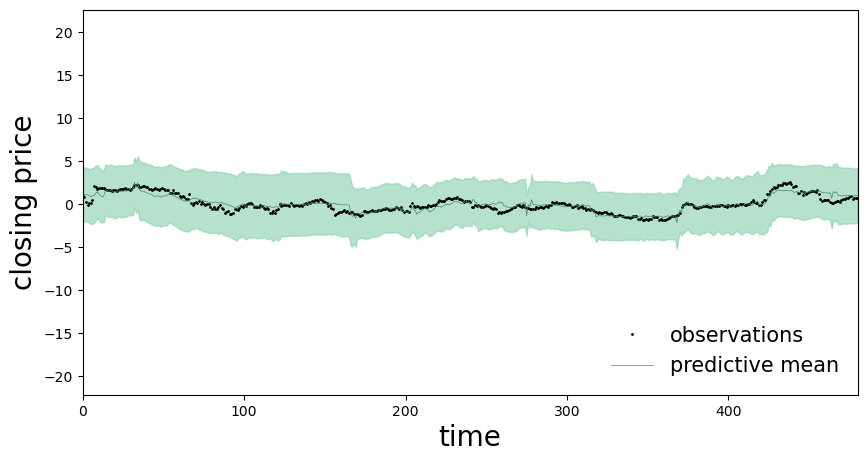

In [75]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_post_n_tensor)

plot_predictions(preds, y_post_n_tensor)

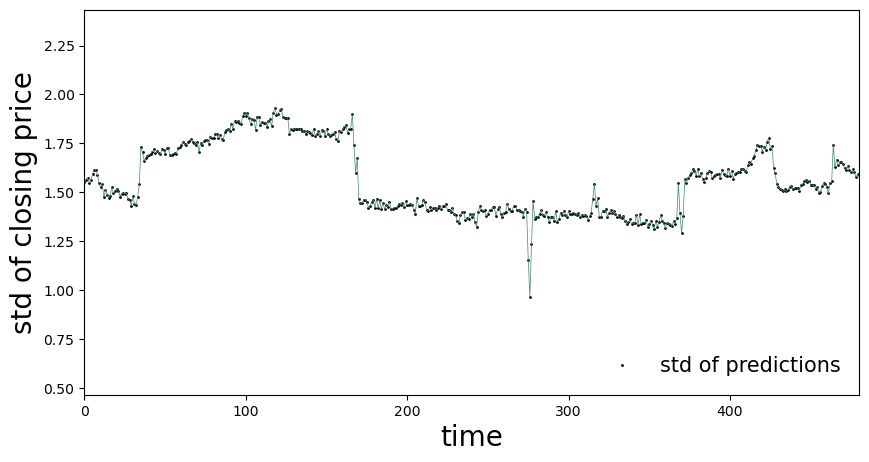

In [76]:
plot_uncertainty(preds, y_post_n)